# Promotional Banner A/B Testing Analysis

## Project Overview

This notebook analyzes the result of an A/B test designed to compare the effectiveness of two promotional banner designs.

The main objective is to determine whether displaying the promotional price as a final price, such as **99K**, leads to a higher conversion rate than displaying the discount amount, such as **-100K**.

The target variable is `is_buy`, where:

- `1` means the customer made a purchase
- `0` means the customer did not make a purchase


## Business Problem

The business wants to understand which promotional message performs better in driving customer purchases.

| Group | Banner Type | Description |
|---|---|---|
| Group 1 | Banner A | Displays the final promotional price, e.g. 99K |
| Group 2 | Banner B | Displays the discount amount, e.g. -100K |

**Key question:** Does Banner A generate a higher conversion rate than Banner B?


## 1. Import Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest


## 2. Load Dataset

Put the dataset in the following path before running this notebook:

```text
data/abtesting.csv
```


In [4]:
DATA_PATH = '/content/abtesting.csv'

df = pd.read_csv(DATA_PATH)
df.head()


,Unnamed: 0,customer_id,group,is_buy
0,0,21393799,2,0
1,1,20349278,2,0
2,2,11655915,2,0
3,3,18516581,2,0
4,4,7805171,2,0


## 3. Dataset Overview


In [5]:
total_records = df.shape[0]
unique_customers = df['customer_id'].nunique()
group_counts = df['group'].value_counts().sort_index()

print(f'Total records: {total_records}')
print(f'Unique customers: {unique_customers}')
print('\nGroup counts:')
print(group_counts)

group_proportions = group_counts / total_records
print('\nGroup proportions:')
print(group_proportions.apply(lambda x: f'{x:.2%}'))


Total records: 30049
Unique customers: 30049

Group counts:
group
1    15025
2    15024
Name: count, dtype: int64

Group proportions:
group
1    50.00%
2    50.00%
Name: count, dtype: object


## 4. Split Data by Group


In [6]:
df_group1 = df[df['group'] == 1]
df_group2 = df[df['group'] == 2]

print(f'Total records in Group 1 / Banner A: {df_group1.shape[0]}')
print(f'Total records in Group 2 / Banner B: {df_group2.shape[0]}')


Total records in Group 1 / Banner A: 15025
Total records in Group 2 / Banner B: 15024


## 5. Calculate Conversion Rate

Conversion rate is calculated as:

```text
Conversion Rate = Number of Buyers / Total Users
```


In [7]:
buyers_group1 = df_group1[df_group1['is_buy'] == 1].shape[0]
total_group1 = df_group1.shape[0]
cr_group1 = buyers_group1 / total_group1 if total_group1 > 0 else 0

buyers_group2 = df_group2[df_group2['is_buy'] == 1].shape[0]
total_group2 = df_group2.shape[0]
cr_group2 = buyers_group2 / total_group2 if total_group2 > 0 else 0

summary = pd.DataFrame({
    'Group': ['Group 1 / Banner A', 'Group 2 / Banner B'],
    'Buyers': [buyers_group1, buyers_group2],
    'Total Users': [total_group1, total_group2],
    'Conversion Rate': [cr_group1, cr_group2]
})

summary['Conversion Rate'] = summary['Conversion Rate'].map(lambda x: f'{x:.2%}')
summary


,Group,Buyers,Total Users,Conversion Rate
0,Group 1 / Banner A,5199,15025,34.60%
1,Group 2 / Banner B,4357,15024,29.00%


## 6. Visualize Conversion Rate


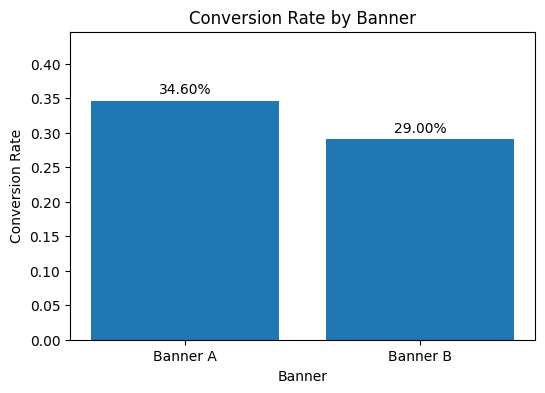

In [8]:
plt.figure(figsize=(6, 4))
plt.bar(['Banner A', 'Banner B'], [cr_group1, cr_group2])
plt.title('Conversion Rate by Banner')
plt.xlabel('Banner')
plt.ylabel('Conversion Rate')
plt.ylim(0, max(cr_group1, cr_group2) + 0.1)

for i, value in enumerate([cr_group1, cr_group2]):
    plt.text(i, value + 0.01, f'{value:.2%}', ha='center')

plt.show()


## 7. Hypothesis Testing

A two-proportion z-test is used because:

- The experiment compares two independent groups
- The target variable is binary: buy or not buy
- The sample size is sufficiently large

### Hypotheses

- **H0:** Conversion Rate A = Conversion Rate B
- **H1:** Conversion Rate A > Conversion Rate B


In [9]:
counts = [buyers_group1, buyers_group2]
observations = [total_group1, total_group2]

z_stat, p_value = proportions_ztest(
    count=counts,
    nobs=observations,
    alternative='larger'
)

print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value:.6f}')


Z-statistic: 10.4261
P-value: 0.000000


## 8. Effect Size


In [10]:
absolute_difference = cr_group1 - cr_group2
relative_difference = absolute_difference / cr_group2 if cr_group2 > 0 else 0

print(f'Absolute difference: {absolute_difference:.2%}')
print(f'Relative difference: {relative_difference:.2%}')


Absolute difference: 5.60%
Relative difference: 19.32%


## 9. Conclusion

If the p-value is smaller than the significance level, for example `alpha = 0.05`, we reject the null hypothesis.

Based on the original analysis, Banner A achieved a higher conversion rate than Banner B, and the difference was statistically significant. Therefore, the recommended decision is:

> **Continue using Banner A and do not replace it with Banner B.**

## Business Interpretation

Customers appear to respond better to seeing the final promotional price directly rather than seeing the discount amount.

## Recommended Improvements

Future analysis can be improved by:

- Adding confidence intervals for conversion rates
- Performing customer segment analysis
- Checking sample balance between groups
- Calculating statistical power
- Estimating business impact in revenue or profit
